# Direct regression — wash_count_total prediction

Target: `wash_count_total` per (site, month).
- **LT2Y model**: train on `less_than-2yrs-nochem.csv` (months 0-23), predict first 2 years.
- **GT2Y model**: train on `more_than-2yrs_monthly-nochem.csv` filtered to msl ≥ 24, predict next 2 years (24-47).

Features: all non-leaky columns + peer-mean from `dg_peer_ids`. 5-fold GroupKFold by site (cold-start).

## Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import xgboost as xgb
import warnings; warnings.filterwarnings('ignore')

RNG = 42
HIT_PCT = 0.20
ABS_TOL = 25000
LT_PATH = '../hypothesis-testing/_no_chem_data/less_than-2yrs-nochem.csv'
GT_PATH = '../hypothesis-testing/_no_chem_data/more_than-2yrs_monthly-nochem.csv'

## Load + compute `month_since_launch`

In [2]:
def load(path):
    df = pd.read_csv(path)
    df['op_date'] = pd.to_datetime(df['operational_start_date'], errors='coerce')
    df['row_date'] = pd.to_datetime(df['calendar_year'].astype(str) + '-' + df['calendar_month'].astype(str).str.zfill(2) + '-01')
    df['msl'] = (df['row_date'].dt.year - df['op_date'].dt.year)*12 + (df['row_date'].dt.month - df['op_date'].dt.month)
    df = df[(df['msl'] >= 0) & (df['wash_count_total'] > 0)].copy()
    # Data hygiene: drop partial-launch months and operational anomalies
    df['op_day'] = df['op_date'].dt.day
    df = df[~((df['msl'] == 0) & (df['op_day'] > 15))]  # mid-month launch = partial msl=0
    df = df[df['wash_count_total'] >= 500]  # drop operational anomalies / soft-opens
    df = df.dropna(subset=['latitude','longitude','dg_peer_ids'])
    df = df[df['dg_peer_ids'].str.len() > 0]
    return df

lt = load(LT_PATH)
gt = load(GT_PATH)
print('lt2y:', lt.shape, '|', lt['client_id_location_id'].nunique(), 'sites,  msl', lt['msl'].min(), '-', lt['msl'].max())
print('gt2y:', gt.shape, '|', gt['client_id_location_id'].nunique(), 'sites,  msl', gt['msl'].min(), '-', gt['msl'].max())

lt2y: (3865, 53) | 219 sites,  msl 0 - 23
gt2y: (10986, 51) | 464 sites,  msl 1.0 - 211.0


## Feature engineering

- Demographics + location + lifecycle (msl, log_msl, month_sin/cos)
- Operational (client_id frequency, tier counts/distances, peer-set quality)
- **`peer_mean_at_msl`** — avg wash_count of peers in `dg_peer_ids` at the same msl, computed train-only per fold (no leakage)
- Excluded as leaky: `avg_monthly_total`, `membership_share`, `prev_wash_count`, `wash_count_retail`, `wash_count_membership`, `fg_peer_feat_dist`

In [3]:
DEMO = ['median_household_income','per_capita_income','population','median_age','median_home_value','pct_owner_occupied']
GEO = ['latitude','longitude']
OP = ['tier_neighbor_count','tier_district_count','tier_metro_count',
      'tier_neighbor_max_km','tier_district_max_km','tier_metro_max_km',
      'nearest_peer_km','dg_peer_count','dg_peer_avg_km','dg_peer_max_km','dg_peer_demo_dist',
      'fg_peer_count','fg_peer_avg_km','fg_peer_max_km']
TIME = ['msl','log_msl','month_sin','month_cos']
FEATS = DEMO + GEO + OP + TIME + ['client_id_freq','peer_mean_at_msl']
TARGET = 'wash_count_total'

def add_time(df):
    df = df.copy()
    df['log_msl'] = np.log1p(df['msl'].astype(float))
    m = df['calendar_month'].astype(float)
    df['month_sin'] = np.sin(2*np.pi*m/12)
    df['month_cos'] = np.cos(2*np.pi*m/12)
    return df

def peer_mean(rows, history):
    base = rows[['client_id_location_id','msl']].copy()
    peers = rows.drop_duplicates('client_id_location_id')[['client_id_location_id','dg_peer_ids']].copy()
    peers['peer_id'] = peers['dg_peer_ids'].str.split(',')
    peers = peers.explode('peer_id')[['client_id_location_id','peer_id']]
    j = base.merge(peers, on='client_id_location_id', how='left')
    h = history[['client_id_location_id','msl','wash_count_total']].rename(
        columns={'client_id_location_id':'peer_id','wash_count_total':'pw'})
    j = j.merge(h, on=['peer_id','msl'], how='left')
    return j.groupby(['client_id_location_id','msl']).agg(peer_mean_at_msl=('pw','mean')).reset_index()

def prep(rows, history):
    rows = add_time(rows)
    freq = history.groupby('client_id').size()
    rows['client_id_freq'] = rows['client_id'].map(freq).fillna(0).astype(float)
    rows = rows.merge(peer_mean(rows, history), on=['client_id_location_id','msl'], how='left')
    for c in FEATS:
        if c not in rows.columns:
            rows[c] = np.nan
        rows[c] = pd.to_numeric(rows[c], errors='coerce')
        rows[c] = rows[c].fillna(rows[c].median() if rows[c].notna().any() else 0.0)
    return rows

## Models + metrics + cross-validation

6 regressors: Ridge, Lasso, RandomForest, GradientBoosting, LightGBM, XGBoost. 5-fold GroupKFold by site.

In [4]:
def models():
    return {
        'Ridge': Ridge(alpha=1.0, random_state=RNG),
        'Lasso': Lasso(alpha=10.0, random_state=RNG, max_iter=5000),
        'RandomForest': RandomForestRegressor(n_estimators=400, max_depth=10, min_samples_leaf=8, n_jobs=-1, random_state=RNG),
        'GradientBoost': GradientBoostingRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, random_state=RNG),
        'LightGBM': lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31, min_child_samples=20, feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5, reg_lambda=2.0, random_state=RNG, n_jobs=-1, verbose=-1),
        'XGBoost': xgb.XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, random_state=RNG, n_jobs=-1, verbosity=0),
    }

def metrics_(y, yhat):
    y = np.asarray(y, dtype=float); yhat = np.asarray(yhat, dtype=float)
    yhat = np.clip(yhat, 0, None)
    ape = np.abs(yhat - y) / np.where(y == 0, 1, y)
    return {
        'MAE': round(mean_absolute_error(y, yhat),1),
        'RMSE': round(float(np.sqrt(mean_squared_error(y, yhat))),1),
        'MAPE_%': round(float(np.mean(ape)*100),1),
        'hit_within_20%_%': round(float(np.mean(ape <= HIT_PCT)*100),1),
        'R2': round(r2_score(y, yhat),3),
    }

def annual_metrics_(preds_df):
    p = preds_df.copy()
    p['tenure_year'] = (p['msl'].astype(float) // 12).astype(int)
    agg = p.groupby(['model','client_id_location_id','tenure_year']).agg(
        actual=('actual','sum'), pred=('pred','sum'), n=('actual','size')).reset_index()
    agg = agg[agg['n'] >= 10]
    agg['abs_err'] = np.abs(agg['pred'] - agg['actual'])
    agg['ape'] = agg['abs_err'] / agg['actual'].clip(lower=1)
    agg['hit_20pct'] = (agg['ape'] <= HIT_PCT).astype(int)
    agg['hit_25k'] = (agg['abs_err'] <= ABS_TOL).astype(int)
    return agg.groupby('model').agg(
        annual_MAE=('abs_err','mean'),
        annual_MAPE_pct=('ape', lambda x: round(float(x.mean()*100),2)),
        hit_20pct=('hit_20pct', lambda x: round(float(x.mean()*100),2)),
        hit_25k=('hit_25k', lambda x: round(float(x.mean()*100),2)),
        n_year_bins=('hit_25k','size'),
    ).reset_index().sort_values('hit_25k', ascending=False)

def run(df, label):
    sites = df['client_id_location_id'].values
    gkf = GroupKFold(n_splits=5)
    monthly = {name: [] for name in models()}
    all_preds = []
    importances = {}
    fold = 0
    for tr_idx, te_idx in gkf.split(df, df[TARGET], groups=sites):
        fold += 1
        tr_raw, te_raw = df.iloc[tr_idx], df.iloc[te_idx]
        tr = prep(tr_raw, tr_raw)
        te = prep(te_raw, tr_raw)
        X_tr, y_tr = tr[FEATS].values, tr[TARGET].values
        X_te, y_te = te[FEATS].values, te[TARGET].values
        base = te[['client_id_location_id','msl']].copy(); base['actual'] = y_te
        for name, m in models().items():
            m.fit(X_tr, y_tr)
            yhat = np.clip(m.predict(X_te), 0, None)
            monthly[name].append(metrics_(y_te, yhat))
            bp = base.copy(); bp['model'] = name; bp['pred'] = yhat
            all_preds.append(bp)
            if fold == 1 and hasattr(m, 'feature_importances_'):
                importances[name] = pd.Series(m.feature_importances_, index=FEATS).sort_values(ascending=False)
    monthly_summary = {name: {k: round(float(pd.DataFrame(runs)[k].mean()),2) for k in ['MAE','RMSE','MAPE_%','hit_within_20%_%','R2']} for name, runs in monthly.items()}
    return pd.DataFrame(monthly_summary).T, pd.concat(all_preds, ignore_index=True), importances

## LT2Y model — first 2 years (months 0-23)

In [5]:
lt_monthly, lt_preds, lt_imp = run(lt, 'lt2y')
print('LT2Y monthly')
lt_monthly.sort_values('hit_within_20%_%', ascending=False)

LT2Y monthly


,MAE,RMSE,MAPE_%,hit_within_20%_%,R2
XGBoost,4231.60,5515.82,75.80,28.04,0.30
Lasso,4539.80,6022.54,85.04,27.90,0.15
Ridge,4545.22,6028.80,85.20,27.66,0.15
GradientBoost,4400.28,5826.62,75.90,27.42,0.22
LightGBM,4334.58,5683.70,76.92,27.10,0.26
RandomForest,4586.20,5950.56,83.36,25.92,0.19


In [6]:
print('LT2Y annual')
annual_metrics_(lt_preds)

LT2Y annual


,model,annual_MAE,annual_MAPE_pct,hit_20pct,hit_25k,n_year_bins
4,Ridge,47509.547884,69.81,31.39,35.77,274
1,Lasso,47425.785405,69.59,30.66,35.40,274
3,RandomForest,48557.093338,68.62,29.20,33.94,274
0,GradientBoost,48123.973179,64.64,24.45,33.21,274
5,XGBoost,46153.454142,64.40,29.56,33.21,274
2,LightGBM,47346.229554,66.07,25.18,28.83,274


## GT2Y model — next 2 years (months 24-47)

In [7]:
gt_next2 = gt[(gt['msl'] >= 24) & (gt['msl'] <= 47)].copy()
print('gt2y filtered to msl 24-47:', gt_next2.shape, '|', gt_next2['client_id_location_id'].nunique(), 'sites')
gt_monthly, gt_preds, gt_imp = run(gt_next2, 'gt2y')
print('\nGT2Y monthly')
gt_monthly.sort_values('hit_within_20%_%', ascending=False)

gt2y filtered to msl 24-47: (4080, 51) | 314 sites



GT2Y monthly


,MAE,RMSE,MAPE_%,hit_within_20%_%,R2
Lasso,5593.14,7643.40,79.86,24.98,-0.11
Ridge,5598.22,7639.80,79.76,24.92,-0.11
RandomForest,5676.52,7712.88,83.58,24.42,-0.13
XGBoost,5398.30,7210.52,75.26,24.16,0.02
LightGBM,5287.48,7128.34,75.06,23.86,0.04
GradientBoost,5615.96,7584.88,77.94,23.34,-0.08


In [8]:
print('GT2Y annual')
annual_metrics_(gt_preds)

GT2Y annual


,model,annual_MAE,annual_MAPE_pct,hit_20pct,hit_25k,n_year_bins
3,RandomForest,64374.552730,70.06,26.05,29.83,238
0,GradientBoost,64952.522717,66.46,27.31,26.89,238
2,LightGBM,61221.824194,63.71,24.79,26.05,238
5,XGBoost,62788.366941,63.92,25.21,25.63,238
1,Lasso,63953.680116,66.81,25.63,23.95,238
4,Ridge,64014.149218,66.71,24.79,23.95,238


## Feature importance — XGBoost (fold 1)

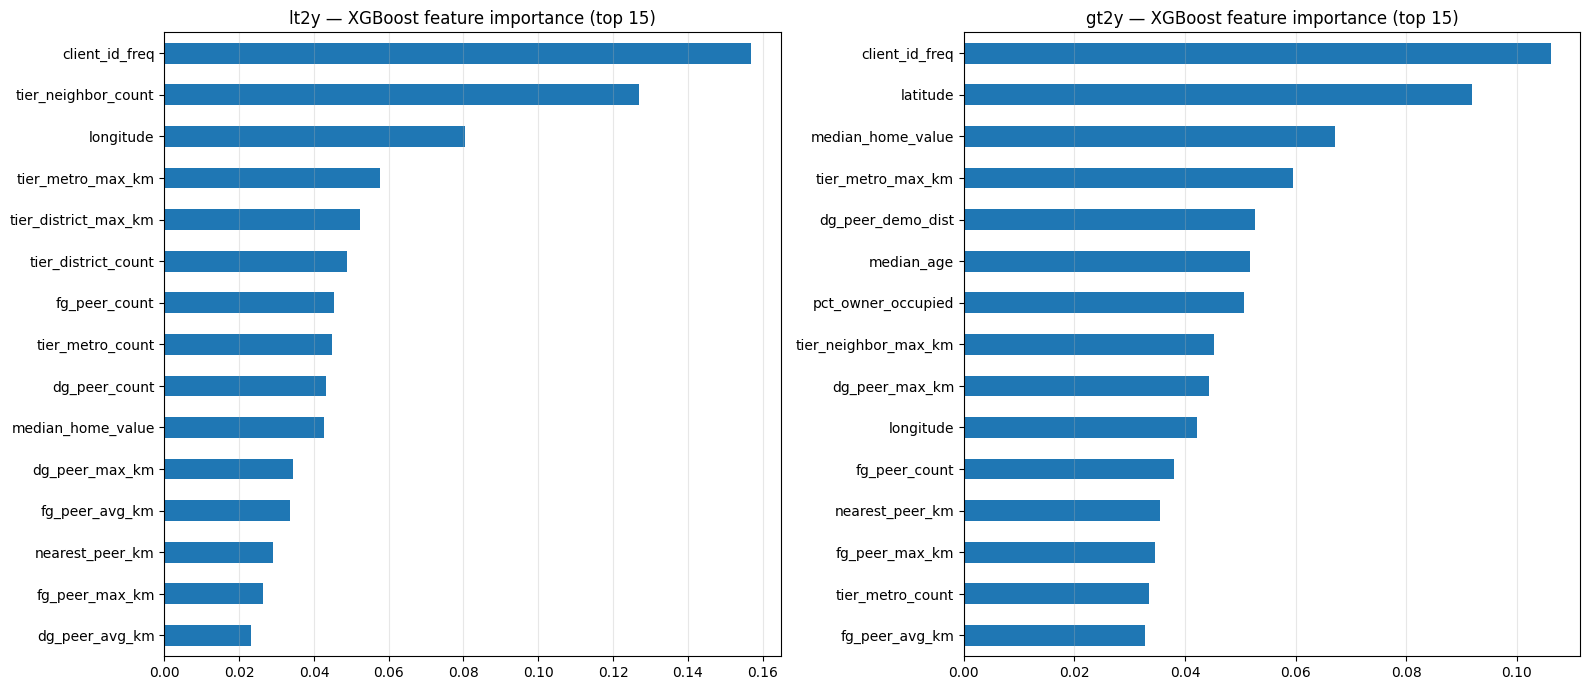

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, imp, label in zip(axes, [lt_imp.get('XGBoost'), gt_imp.get('XGBoost')], ['lt2y','gt2y']):
    if imp is None: continue
    imp.head(15).sort_values().plot(kind='barh', ax=ax, color='#1f77b4')
    ax.set_title(f'{label} — XGBoost feature importance (top 15)')
    ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## Combined benchmark — monthly + annual side by side

In [10]:
lt_m = lt_monthly.copy(); lt_m['cohort'] = 'lt2y'; lt_m['model'] = lt_m.index
gt_m = gt_monthly.copy(); gt_m['cohort'] = 'gt2y'; gt_m['model'] = gt_m.index
monthly_all = pd.concat([lt_m, gt_m])[['cohort','model','MAE','RMSE','MAPE_%','hit_within_20%_%','R2']].reset_index(drop=True)
lt_a = annual_metrics_(lt_preds).assign(cohort='lt2y')
gt_a = annual_metrics_(gt_preds).assign(cohort='gt2y')
annual_all = pd.concat([lt_a, gt_a])[['cohort','model','annual_MAE','annual_MAPE_pct','hit_20pct','hit_25k','n_year_bins']].reset_index(drop=True)
print('=== Monthly ===')
display(monthly_all.sort_values(['cohort','hit_within_20%_%'], ascending=[True, False]).reset_index(drop=True))
print('\n=== Annual ===')
display(annual_all.sort_values(['cohort','hit_25k'], ascending=[True, False]).reset_index(drop=True))

=== Monthly ===


,cohort,model,MAE,RMSE,MAPE_%,hit_within_20%_%,R2
0,gt2y,Lasso,5593.14,7643.40,79.86,24.98,-0.11
1,gt2y,Ridge,5598.22,7639.80,79.76,24.92,-0.11
2,gt2y,RandomForest,5676.52,7712.88,83.58,24.42,-0.13
3,gt2y,XGBoost,5398.30,7210.52,75.26,24.16,0.02
4,gt2y,LightGBM,5287.48,7128.34,75.06,23.86,0.04
5,gt2y,GradientBoost,5615.96,7584.88,77.94,23.34,-0.08
6,lt2y,XGBoost,4231.60,5515.82,75.80,28.04,0.30
7,lt2y,Lasso,4539.80,6022.54,85.04,27.90,0.15
8,lt2y,Ridge,4545.22,6028.80,85.20,27.66,0.15
9,lt2y,GradientBoost,4400.28,5826.62,75.90,27.42,0.22



=== Annual ===


,cohort,model,annual_MAE,annual_MAPE_pct,hit_20pct,hit_25k,n_year_bins
0,gt2y,RandomForest,64374.552730,70.06,26.05,29.83,238
1,gt2y,GradientBoost,64952.522717,66.46,27.31,26.89,238
2,gt2y,LightGBM,61221.824194,63.71,24.79,26.05,238
3,gt2y,XGBoost,62788.366941,63.92,25.21,25.63,238
4,gt2y,Lasso,63953.680116,66.81,25.63,23.95,238
5,gt2y,Ridge,64014.149218,66.71,24.79,23.95,238
6,lt2y,Ridge,47509.547884,69.81,31.39,35.77,274
7,lt2y,Lasso,47425.785405,69.59,30.66,35.40,274
8,lt2y,RandomForest,48557.093338,68.62,29.20,33.94,274
9,lt2y,GradientBoost,48123.973179,64.64,24.45,33.21,274
